![D590](https://homes.luddy.indiana.edu/skavousi/d590/banner.png)
# Final Project

In [ ]:
# This cell downloads all supplemental materials required for this
# assignment. Run it before working on the questions.
from os.path import basename, exists

def download(url, f=False):
    filename = basename(url)
    if f or not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://homes.luddy.indiana.edu/skavousi/d590/breast-cancer-wisconsin.data')

<div class="alert alert-block alert-success">  
<b>Notes:</b>
    
- Use `pandas` to perform vectorized operations on DataFrames and Series.<br>
    
- Do not alter the given function names specified in the assignment prompt. Your task is to concentrate your coding efforts solely within those specified sections.

- Don't forget to call the relevant functions in your notebook after completing your answers. Display the results or output of calling the functions to demonstrate their functionality.
</div>

<div class="alert alert-block alert-info">

# Problem Statement
The objective of the final project is to implement $k$-means algorithm for Wisconsin Breast Cancer data set using Python.

Breast cancer is a rising issue among women. A cancer’s stage is a crucial factor in deciding what
treatment options to recommend, and in determining the patient’s prognosis. Today, in the United States,
approximately one in eight women over their lifetime has a risk of developing breast cancer. An analysis
of the most recent data has shown that the survival rate is 88% after 5 years of diagnosis and 80% after 10
years of diagnosis. With early detection and treatment, it is possible that this type of cancer will go into
remission. In such a case, the worse fear of a cancer patient is the recurrence of the cancer.
 
In the final project we will address this issue by using k-means clustering to analyze cancer data and
classify patients into two different groups, one with benign and the other one with malign cells. You will
implement $k$-means clustering program in Python and test it on famous Wisconsin Breast Cancer Data.
    
</div>


<div class="alert alert-block alert-info">

# Data Set
    
Wolberg’s breast cancer data can be found [here](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Samples arrive periodically as Dr. Wolberg reports his
clinical cases. There are 11 columns (attributes) in this data set. The first column contains Sample code
number (SCN), which is the patient id number.

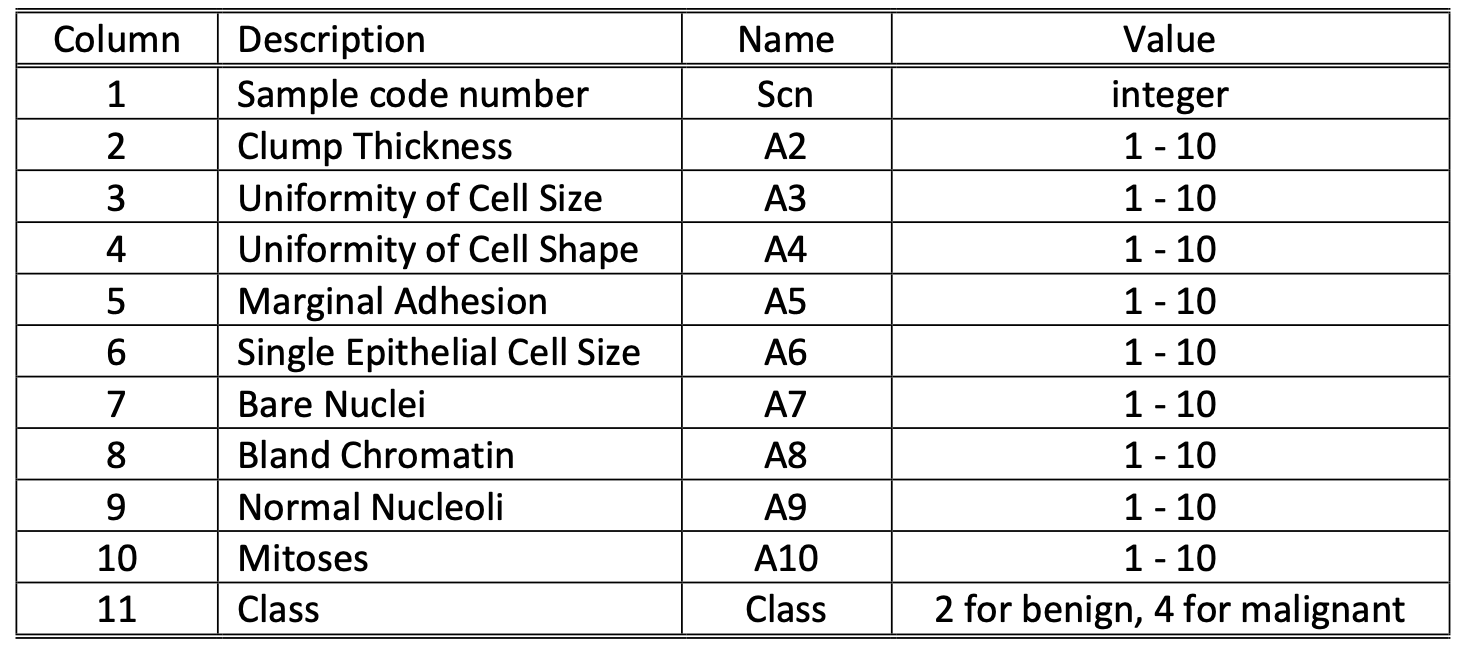

</div>


<div class="alert alert-block alert-info"> 
    
# Phase 1 (Done in Assignment 7)
    
This project has been designed to be completed in two weeks. You have finished this part already in Assignment 07. 
</div>

<div class="alert alert-block alert-info">

# Phase 2
    
You will implement $k$-means algorithm in the second phase. We suggest that you revise $k$-means clustering to make sure that you understand the algorithm before writing code. 
    
In the Wisconsin Breast Cancer data set, `Scn` is the first and `Class` is the last column. We do not consider these two columns for $k$-means computation.  
    
Use the dataset with imputed missing values from phase 1 and use columns `A2` to `A10` for $k$-means computation.

## Instructions

The steps in phase 2 include:

- Write code for `initial` Step
- Write code for `assign` Step
- Write code for `recompute` Step
    
    
#### a) Write code for `initial` step

Randomly choose two points from data set as the initial centroids. Since you only consider column `A2` to `A10`, an initial centroid is a nine dimensional vector. Give first centroid name $\mu_{2}$ and second centroid name $\mu_{4}$
<br>   

<div class="alert alert-block alert-warning">  
<b>Hints:</b> 

Example:
    
Let’s say randomly selected data points are $6$ and $246$ as two initial centroids. So values of $\mu_{2}$ and
$\mu_{4}$ are
    
$\mu_{2} = (8, 10, 10, 8, 7, 10, 9, 7, 1)$<br>
$\mu_{4} = (5, 1, 1, 2, 2, 2, 3, 1, 1)$
    
</div>

<div class="alert alert-block alert-warning">  
<b>Note:</b> 
    
You need to select two initial centroids randomly. So every time the code runs, two different initial centroids are selected. You may use `numpy random` library to select random points from the data set   
</div>

#### b) Write code for `assign` step

For each one of 699 data points compute Euclidian distance from the two centroids. Use initial centroids in the first iteration. In the rest of the iterations use the centroids calculated in step *c* of the previous iteration.
    
At the end of this step, each data point will be assigned to one of the two clusters, which we call predicted clusters. Store the information on `predicted clusters` into a column `Predicted_Class`. 
    
For each data point the value of `Predicted_Class` will be:
    
- `Predicted_Class = 2`, if the program calculates that the corresponding data point is in the cluster $2$ that corresponds to centroid $\mu_{2}$
- `Predicted_Class = 4`, if the program calculates that the corresponding data point is in the cluster $4$ that corresponds to centroid $\mu_{4}$

This step calculates two distances for each data point. Assign a data point to cluster 2
(`Predicted_Class = 2`) if its distance from $\mu_{2}$ is closer than its distance from $\mu_{4}$; assign the data
point to cluster 4 (`Predicted_Class = 4`) otherwise.
    
<div class="alert alert-block alert-warning">  
<b>Hints:</b> 
    
Example:
    
Let’s take a data point at row number $375$ and compute its distance $d$ from both centroids.
data point $375 = (3, 1, 2, 1, 2, 1, 2, 1, 1)$<br>
$d(375,\mu_{2})=\sqrt{(3-8)^2+(1-10)^2+(2-10)^2... ...+(1-1)^2}=20.25\\
d(375,\mu_{4})=\sqrt{(3-5)^2+(1-1)^2+(2-1)^2... ...+(1-1)^2}=2.83$

Since $d(375,\mu_{4}) < d(375,\mu_{2})$, data point at row number $375$ will be assigned to cluster $4$
    
</div>  
    
#### c) Write code for `recompute` step

So far, you have assigned each data point to one of the two clusters. Next, you will update the centroids.  
    
<div class="alert alert-block alert-warning">  
<b>Hints:</b> 

Example:
    
Let’s say after performing step *b*, you have $300$ data points assigned to cluster $2$ (i.e. `Predicted_Class = 2` ), and remaining $399$ data points assigned to cluster 4 (`Predicted_Class = 4`). Update $\mu_{2}$ by computing the mean from cluster 2 data points and update $\mu_{4}$ by computing the mean from cluster 4 data points.
   
</div>    

#### d) Iterate steps *b* and *c* until any one of the following conditions is true:
    
1. Centroids ( or clusters) don’t change compared to the previous iteration.
    
2. Steps *b* and *c* iterated $50$ times.
    
At the end step *d*, you will have final values of the centroids and predicted clusters. Print this result in console. 
    
</div>

In [84]:
# Load the dataset 
import pandas as pd
import numpy as np

# these were done in assignment 7
# Read the file,  "?" as missing values 
df = pd.read_csv("breast-cancer-wisconsin.csv", na_values="?")

# Impute missing values with column means 
df = df.fillna(df.mean(numeric_only=True))

# A2–A10 for kmeans
kmean_data = df[["A2","A3","A4","A5","A6","A7","A8","A9","A10"]]

In [85]:
def initial(data):
    """Randomly choose two points from data set as the initial centroids.
    Give first centroid name mu2 and second centroid name mu4 """

    # randomly select 2 rows
    # data.index numbers the rows.
    # output example: initial_centroids = [12, 57]
    initial_centroids = np.random.choice(data.index, size=2, replace=False) 

    # note to self: [0], and [1] because out output from last line.
    mu_2 = data.loc[initial_centroids[0]].values #randomly chosen row 1
    mu_4 = data.loc[initial_centroids[1]].values #randomly chosen row 2

    # print which rows were chosen and the actual values
    print(f"Randomly selected row {initial_centroids[0]} for centroid μ₂.")
    print("Initial centroid μ₂:")
    print(data.loc[initial_centroids[0]])
    
    print(f"\nRandomly selected row {initial_centroids[1]} for centroid μ₄.")
    print("Initial centroid μ₄:")
    print(data.loc[initial_centroids[1]])
    
    return mu_2, mu_4
    
mu_2,mu_4 = initial(kmean_data)

Randomly selected row 633 for centroid μ₂.
Initial centroid μ₂:
A2      8.0
A3      7.0
A4      4.0
A5      4.0
A6      5.0
A7      3.0
A8      5.0
A9     10.0
A10     1.0
Name: 633, dtype: float64

Randomly selected row 688 for centroid μ₄.
Initial centroid μ₄:
A2     4.0
A3     1.0
A4     1.0
A5     1.0
A6     2.0
A7     1.0
A8     1.0
A9     1.0
A10    1.0
Name: 688, dtype: float64


In [86]:
def assign(data, mu_2, mu_4):
    """calculate and assign each data point to the nearest centroid.
    stores 2 or 4 in new column Predicted_Class"""

    # convert pandas into numpy, easier to do math. (turning a table into list of numbers)
    data_array = data.values

    # calculate Euclidean distance to each centroid
    distance_to_mu2 = np.sqrt(np.sum((data_array - mu_2) ** 2, axis=1)) #distance to mu_2
    distance_to_mu4 = np.sqrt(np.sum((data_array - mu_4) ** 2, axis=1)) #distance to mu_4

    # if distance to mu2 is smaller, assign 2, else assign 4
    predicted_class = np.where(distance_to_mu2 < distance_to_mu4, 2, 4)

    # make a copy to keep orignial data when rerunning the code again.
    # add new column "predicted class"
    data_with_clusters = data.copy()
    data_with_clusters["Predicted_Class"] = predicted_class

    return data_with_clusters

# initial step: choose centroids from kmeans_data
mu_2, mu_4 = initial(kmean_data)

# assign: assign each row to nearest centroid
cluster_result = assign(kmean_data, mu_2, mu_4)

print(cluster_result.head())

Randomly selected row 437 for centroid μ₂.
Initial centroid μ₂:
A2     4.0
A3     1.0
A4     1.0
A5     1.0
A6     2.0
A7     1.0
A8     1.0
A9     1.0
A10    1.0
Name: 437, dtype: float64

Randomly selected row 664 for centroid μ₄.
Initial centroid μ₄:
A2     3.0
A3     1.0
A4     1.0
A5     3.0
A6     2.0
A7     1.0
A8     2.0
A9     1.0
A10    1.0
Name: 664, dtype: float64
   A2  A3  A4  A5  A6    A7  A8  A9  A10  Predicted_Class
0   5   1   1   1   2   1.0   3   1    1                2
1   5   4   4   5   7  10.0   3   2    1                4
2   3   1   1   1   2   2.0   3   1    1                4
3   6   8   8   1   3   4.0   3   7    1                2
4   4   1   1   3   2   1.0   3   1    1                4


In [87]:
def recompute(data_with_clusters):
    """recalculate the centroids, finidng average for new mu_2 and new mu_4"""

    # select rows that belongs to cluster 2
    # .iloc[:, :-1] drops the predicted class column, we only need the numbers that's in cluster 2
    cluster2_points = data_with_clusters[data_with_clusters["Predicted_Class"] == 2].iloc[:, :-1]

    # select rows that belongs to cluster 4
    cluster4_points = data_with_clusters[data_with_clusters["Predicted_Class"] == 4].iloc[:, :-1]

    # .mean (calculates mean)
    # axis = 0 (each column)
    # .values into numpy array
    mu_2 = cluster2_points.mean(axis=0).values
    mu_4 = cluster4_points.mean(axis=0).values

    # this will be the new mu_2 and new mu_4
    return mu_2, mu_4

new_mu_2, new_mu_4 = recompute(cluster_result)
print("Updated μ₂:", new_mu_2)
print("Updated μ₄:", new_mu_4)

Updated μ₂: [4.91085271 2.05813953 2.21705426 1.17829457 2.53100775 2.18884992
 2.20542636 1.95736434 1.31782946]
Updated μ₄: [4.1292517  3.76417234 3.78684807 3.75963719 3.61678005 4.33784856
 4.15873016 3.39909297 1.74829932]


In [88]:
def kmeans(data, maximum_iterations=50):
    """
    this function runs the full kmeans algorithm.
    - picks starting centroid
    - assign points
    - recalculate centroids
    - stops when centroids stop changing or until it loops 50 times
    """
    
    # initial function
    # randomly selecting 2 rows to begin as initial centroids
    mu_2, mu_4 = initial(data)

    # 50 time loops (0 to 49)
    for iteration in range(maximum_iterations):
        # assign function
        clustered_data = assign(data, mu_2, mu_4)
        
        # recompute function
        new_mu_2, new_mu_4 = recompute(clustered_data)
        
        # check if new centroid are same as old ones
        # np.array_equal(a,b) checks if a and b are the same shape and same number in same order
        if np.array_equal(new_mu_2, mu_2) and np.array_equal(new_mu_4, mu_4):
            print(f"\nProgram ended after {iteration+1} iterations. The centroids stopped changing")
            break # if centroid stops changing then break the loop
        
        mu_2, mu_4 = new_mu_2, new_mu_4
    else:
        print(f"\nProgram ended after {max_iters} iterations (50 iterations reached).")
    
    # Print final centroids
    print("\nFinal centroid μ₂:") #prints on new line
    print(pd.Series(mu_2, index=data.columns)) #pd.series turns the list of numbers into a table.
                                               # index = data.columns uses column names as labels

    #final centroid for mu_4
    print("\nFinal centroid μ₄:")
    print(pd.Series(mu_4, index=data.columns))
    
    # these are for the sample output below: final cluster assignment table (Scn, CLASS, Predicted_Class)
    final_result = df[["Scn","CLASS"]].copy()
    final_result["Predicted_Class"] = clustered_data["Predicted_Class"].values
    
    return final_result, mu_2, mu_4

In [89]:
# Run with kmean_data
final_clusters, final_mu2, final_mu4 = kmeans(kmean_data)

Randomly selected row 236 for centroid μ₂.
Initial centroid μ₂:
A2     10.0
A3      8.0
A4      8.0
A5      2.0
A6      8.0
A7     10.0
A8      4.0
A9      8.0
A10    10.0
Name: 236, dtype: float64

Randomly selected row 530 for centroid μ₄.
Initial centroid μ₄:
A2      7.0
A3      4.0
A4      4.0
A5      3.0
A6      4.0
A7     10.0
A8      6.0
A9      9.0
A10     1.0
Name: 530, dtype: float64

Program ended after 7 iterations. The centroids stopped changing

Final centroid μ₂:
A2     7.158798
A3     6.798283
A4     6.729614
A5     5.733906
A6     5.472103
A7     7.873966
A8     6.103004
A9     6.077253
A10    2.549356
dtype: float64

Final centroid μ₄:
A2     3.047210
A3     1.302575
A4     1.446352
A5     1.343348
A6     2.087983
A7     1.380001
A8     2.105150
A9     1.261803
A10    1.109442
dtype: float64


In [90]:
# Print the header message
print("Final cluster assignment:")

# first 20 rows
print(final_clusters.head(20))

Final cluster assignment:
        Scn  CLASS  Predicted_Class
0   1000025      2                4
1   1002945      2                2
2   1015425      2                4
3   1016277      2                2
4   1017023      2                4
5   1017122      4                2
6   1018099      2                4
7   1018561      2                4
8   1033078      2                4
9   1033078      2                4
10  1035283      2                4
11  1036172      2                4
12  1041801      4                4
13  1043999      2                4
14  1044572      4                2
15  1047630      4                4
16  1048672      2                4
17  1049815      2                4
18  1050670      4                2
19  1050718      2                4


#### Sample Output

<pre>
Randomly selected row 148 for centroid mu_2.
Initial centroid mu_2:
A2      3.0
A3      1.0
A4      1.0
A5      3.0
A6      8.0
A7      1.0
A8      5.0
A9      8.0
A10     1.0
Name: 148, dtype: float64

Randomly selected row 190 for centroid mu_4.
Initial centroid mu_4:
A2      10.0
A3      10.0
A4      10.0
A5      8.0
A6      6.0
A7      8.0
A8      7.0
A9      10.0
A10     1.0
Name: 190, dtype: float64

Program ended after 4 iterations.
Final centroid mu_2:
A2    3.047210
A3    1.302575
A4    1.446352
A5    1.343348
A6    2.087983
A7    1.380001
A8    2.105150
A9    1.261803
A10   1.109442
dtype: float64

Final centroid mu_4:
A2    7.158798
A3    6.798283
A4    6.729614
A5    5.733906
A6    5.472103
A7    7.873966
A8    6.103004
A9    6.077253
A10   2.549356
dtype: float64
<pre>



Final cluster assignment:
<pre>
    Scn   Class Predicted_Class
0  1000025 2    2
1  1002945 2    4
2  1015425 2    2
3  1016277 2    4
4  1017023 2    2
5  1017122 4    4
6  1018099 2    2
7  1018561 2    2
8  1033078 2    2
9  1033078 2    2
10 1035283 2    2
11 1036172 2    2
12 1041801 4    2
13 1043999 2    2
14 1044572 4    4
15 1047630 4    2
16 1048672 2    2
17 1049815 2    2
18 1050670 4    4
19 1050718 2    2
20 1054590 4    4
<pre>

<div class="alert alert-block alert-warning">  
<b>Notes:</b> 

- You can pass arguments to the function if required.
- Your output may be different than the above. Include the first $20$ data points (rows) in your report.
- This version of $k$-means algorithm may suffer from poor initialization. Therefore, you may see different answers or swapped cluster assignments. We recommend running program multiple times and submitting the best results. 
</div>

<div class="alert alert-block alert-danger"> 

# Submission Guidelines for Final Project
    
- You should submit a single Jupyter Notebook (.ipynb) with your solutions for this assignment. The notebook must be the same one we provided you for this assignment, modified with your solutions. The results should include the initial and final centroids and cluster assignment with first 20 data points.    
- Make sure your code is properly formatted, structured and commented. The statements in the program have to properly indented. 
- Make sure that your program runs without any errors. A program that throws an error is usually scored 0 points.
</div>